# Task 1 - The overview

a) I'm using the python module from Bjørklund here because I want to write everything in python. I´ve done some modifcations to the data processing though, but should yield the same result.

In [ ]:
import bjorklund_extracts as be
# Extract station data
station_data = be.parse_h5_station_data()

In [ ]:
# Plot the station map
be.plot_map(station_data, be.TONGA_LAT_LON)
# Calculate the distances
distances = be.circle_distance(station_data, be.TONGA_LAT_LON)

b) Based on the data analyzed above the shortest great circle distance is 2137.71km. Largest great circle distance is 17687.13km.
c) See plot above.

# Task 2 - Data filtering

a) Plotting the three different FIR filter responses.

In [ ]:
import matias_project as ma
import matplotlib.pyplot as plt
import numpy as np

# Im taking the FFT of the three filters and plotting their magnitude responses
# this will give me their frequency responses
H1 = np.fft.rfft(ma.h1)
H2 = np.fft.rfft(ma.h2)
H3 = np.fft.rfft(ma.h3)
f = np.fft.rfftfreq(len(ma.h1))
fig, ax = plt.subplots()
ax.plot(f, np.abs(H1), label='h1')
ax.plot(f, np.abs(H2), label='h2')
ax.plot(f, np.abs(H3), label='h3')
ax.set_xlabel('Normalized frequency [Fs]')
ax.set_ylabel('Magnitude')
ax.set_title('FIR filter frequency responses')
ax.legend()
plt.show()


b) Checking my implmentation with numpy standard.


In [ ]:
# b) Checking my implmentation with numpy standard.
x = np.random.randn(1000)
np_convolved = np.convolve(x, ma.h1, mode='full')
ma_convolved = ma.convolve_signal_with_filter(h=ma.h1, x=x)
print("Are the two convolutions equal? ", np.allclose(np_convolved, ma_convolved))

c) Coding up a DFT method. See implementation in matias_project.py
d) Using this method to plot the frequency spectrum of h1, h2 and h3.

In [ ]:
N = 2048
H1_dft, freq_H1 = ma.dft(ma.h1, N=N)
H2_dft, freq_H2 = ma.dft(ma.h2, N=N)
H3_dft, freq_H3 = ma.dft(ma.h3, N=N)

fig, ax = plt.subplots()
ax.plot(freq_H1, np.abs(H1_dft), label='h1 DFT')
ax.plot(freq_H2, np.abs(H2_dft), label='h2 DFT')
ax.plot(freq_H3, np.abs(H3_dft), label='h3 DFT')
ax.set_xlabel('Normalized frequency [Fs]')
ax.set_ylabel('Magnitude')
ax.set_title('FIR filter frequency responses using DFT')
ax.legend()
plt.show()

# Same plot but skipping the nyquist(alias) frequencies
fig, ax = plt.subplots()
ax.plot(freq_H1[:N//2], np.abs(H1_dft[:N//2]), label='h1 DFT')
ax.plot(freq_H2[:N//2], np.abs(H2_dft[:N//2]), label='h2 DFT')
ax.plot(freq_H3[:N//2], np.abs(H3_dft[:N//2]), label='h3 DFT')
ax.set_xlabel('Normalized frequency [Fs]')
ax.set_ylabel('Magnitude')
ax.set_title('FIR filter frequency responses using DFT (Nyquist frequencies skipped)')
ax.legend()
plt.show()

e) As we can see above the h1 filter is a Lowpass filter, h2 a Bandpass filter and h3 a Highpass filter. It is a little bit hard to see h1. But it follows the orange h2 line.

f) Filtering all the data. As can be seen by modified "bjorklund_extracts.py" Ive chosen to use a Dataclass to hold all the data called StationData. I now convert this dataclass to StationDataFiltered, stored in "matias_project.py". Lastly I save this list of StationDaaFiltered to .pickle file to not have to do the computation again.

In [ ]:
station_data_filtered = list[ma.StationDataFiltered]()
for sd in station_data:
    station_data_filtered.append(ma.filter_station_data(sd))
ma.save_filtered_data(station_data_filtered)

g) I pivoted my code completly in this task. After spending hours almost writing the whole "plot_section" method (which was linked to in the task) for my StationDataFiltered class, and not getting any nice results. I realized that I should rather use the "obspy" library directly. After further investigation, I also saw that the data stored in the H5 files actually are "obspy" objects! Making this a lot easier. I choose to not re-write the code above, to keep some of the old work. But from here on, I actually import the data again into an "obspy.stream" instead, using the "ma.pase_h5_to_obspy_station_data". Everything just became a breeze.

Answer to this task question:
 Since all all sample periods are 0.1sec in the data. This gives me a Fs=1/0.1=10Hz. Based on the image above, if I choose the h2 filter this will give me a lower cut-off around 0.001*10Hz=0.01Hz and a high frequency cut-off arund 0.2*10=2Hz

 I think the plot generated by the code is very similar as the plot 2C in the task description, however, it seems like I have slightly less data.

In [ ]:
import matias_project as ma
import numpy as np
stream = ma.parse_h5_to_obspy_station_data()
# Loop over the streams and apply filter h2
for tr in stream:
    tr.data = np.convolve(ma.h2, tr.data, mode="same")

# This code just got so much easier using obspy directly!
ma.plot_section(stream)

# Task 3 - Estimating the celerity of the globally propagating acoustic wave

a) First looping the stations, picking arival time in the metod "pick_arrival_time". Ive created a Dataclass objet called ArrivalTimePick in "matias_project.py" which I alos save to a pickle file after the picking is done.

In [ ]:
# Since jupyter is non-interactive Ive ran this code below in a script
# and saved the output to a pickle file. I then load the pickle file here.
# stream = ma.parse_h5_to_obspy_station_data()
# arrival_time = ma.pick_arrival_time(stream)

import pathlib
import matias_project as ma
import pickle
arrival_time_loaded = ma.load_arrival_times(pathlib.Path("arrival_times_start_0_stop_200.pkl"))


Loaded 201 arrival time picks from arrival_times_start_0_stop_200.pkl


b) Loading inn the data and plotting it first.

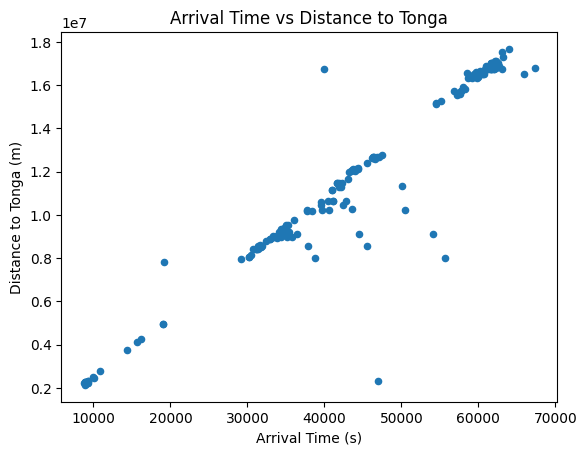

In [11]:
# Plotting the arrival times vs distance
import pandas as pd
import matplotlib.pyplot as plt
df_arrival_time = pd.DataFrame(arrival_time_loaded)
df_arrival_time.plot.scatter(x="arrival_time", y="distance_to_tonga")
plt.ylabel("Distance to Tonga (m)")
plt.xlabel("Arrival Time (s)")
plt.title("Arrival Time vs Distance to Tonga")
plt.show()


As can be seen, some of the data seems like wrong pickes. I have choosen to remove some of these values.

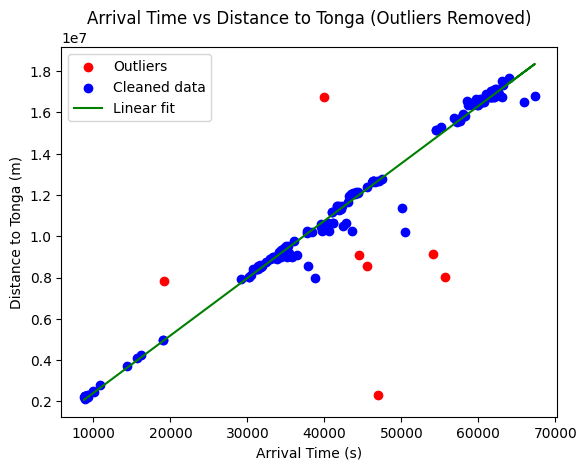

Estimated celerityvelocity from linear fit: 277.79 m/s


In [17]:
import numpy as np
# Removing some of the outliers based on visual inspection of the plot above
df_outliers = df_arrival_time[
    ((df_arrival_time["arrival_time"] < 23000) & (df_arrival_time["distance_to_tonga"] >0.6e7))
    | ((df_arrival_time["arrival_time"] < 50000) & (df_arrival_time["distance_to_tonga"] > 1.6e7))
    | ((df_arrival_time["arrival_time"] > 40000) & (df_arrival_time["distance_to_tonga"] < 0.95e7))
    
    ]

# Get the outliers for plotting
df_outliers_removed = df_arrival_time.drop(df_outliers.index)

# PLotting the cleaned data together with the removed outliers, and the linear fit of the cleaned data
fig, ax = plt.subplots()
ax.scatter(df_outliers["arrival_time"], df_outliers["distance_to_tonga"], label="Outliers", color='red')
ax.scatter(df_outliers_removed["arrival_time"], df_outliers_removed["distance_to_tonga"], color='blue', label="Cleaned data")
# Linear fit
m, b = np.polyfit(df_outliers_removed["arrival_time"], df_outliers_removed["distance_to_tonga"], 1)
ax.plot(df_outliers_removed["arrival_time"], m * df_outliers_removed["arrival_time"] + b, color='green', label="Linear fit")
ax.set_xlabel("Arrival Time (s)")
ax.set_ylabel("Distance to Tonga (m)")
ax.set_title("Arrival Time vs Distance to Tonga (Outliers Removed)")
ax.legend()
plt.show()
# Calculating the velocity from the slope of the linear fit
velocity = m    # in m/s
print(f"Estimated celerityvelocity from linear fit: {velocity:.2f} m/s")

I'm pretty happy about this plot. I get an estimated celerity of 277.79m/s. On page 3 of Matoza et al. (2022) they mention that typical celerities of infrasound waves have group velocity between 250 and 290 m/s. I'm spot on in the middle here!